In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from dateutil.relativedelta import relativedelta


In [3]:
df= pd.read_csv('../data/DataWave_Music_cleaned.csv')

In [4]:
df.head()

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date
0,U1403,nepal,23,Female,Premium,11.5,510,0.05,2.0,0,7.99,21/03/2024
1,U1165,nepal,63,Male,Student,11.3,526,0.05,3.0,0,0.00,08/10/2023
2,U1474,usa,45,Female,Premium,2.0,476,0.30,3.0,0,7.99,04/05/2022
3,U1478,nigeria,16,Female,Family,12.1,529,0.20,5.0,1,12.99,16/12/2023
4,U1609,ghana,29,Male,Free,6.4,477,0.20,3.0,0,7.99,28/03/2022


In [5]:
df.loc[df['subscription_type'] == 'Student', ["user_id","country",'age','gender','subscription_type','avg_listening_hours_per_week','total_songs_played',	"skip_rate","satisfaction_score",	"churned","monthly_fee",'join_date']] 

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date
1,U1165,nepal,63,Male,Student,11.3,526,0.05,3.0,0,0.00,08/10/2023
5,U1691,united kingdom,16,Female,Student,11.0,548,0.30,3.0,0,9.99,25/04/2022
8,U1514,india,23,Female,Student,21.5,514,0.15,3.0,0,9.99,12/02/2022
11,U1158,kenya,64,Male,Student,7.6,440,0.10,5.0,0,7.99,09/05/2022
13,U1120,ghana,46,Male,Student,11.2,509,0.20,5.0,1,9.99,15/02/2023
...,...,...,...,...,...,...,...,...,...,...,...,...
666,U1269,united kingdom,37,Female,Student,12.0,456,0.05,2.0,0,9.99,05/11/2022
671,U1329,united kingdom,48,Male,Student,9.7,530,0.10,1.0,0,7.99,15/05/2023
684,U1415,ghana,53,Male,Student,5.8,506,0.30,3.0,1,12.99,23/11/2022
686,U1680,kenya,59,Female,Student,23.6,495,0.05,2.0,1,5.00,31/07/2023


In [6]:
total_per_country = df.groupby('country').size()

In [7]:
county_churn = df[df['churned'] == 1].groupby('country').size()
churn_percentage = (county_churn /total_per_country ) *100
print('Churn percentage for eacch country(%) :')
print(churn_percentage.round(2))

Churn percentage for eacch country(%) :
country
brazil            38.46
ghana             36.21
india             23.89
kenya             32.31
nepal             26.09
nigeria           36.92
south africa      27.78
united kingdom    32.60
usa               22.97
dtype: float64


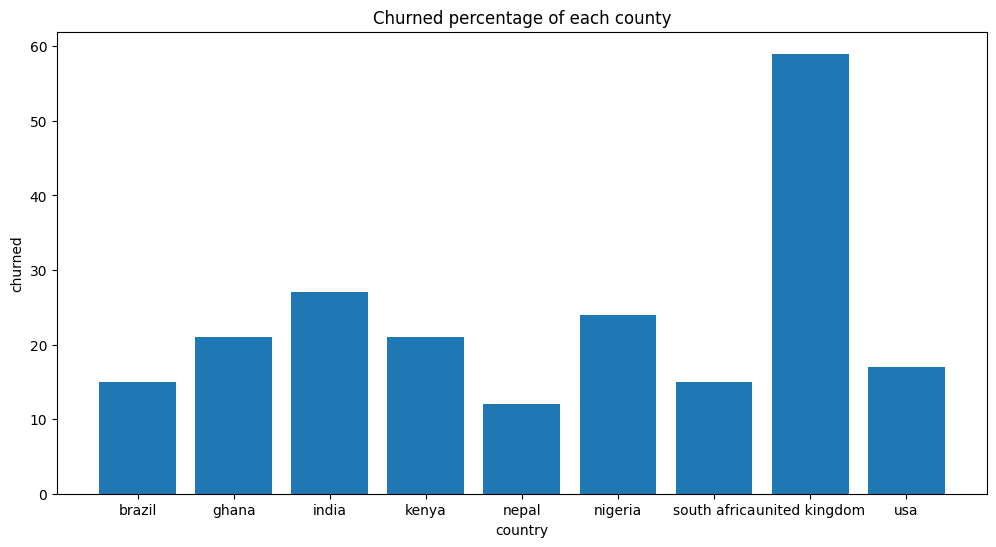

In [8]:
plt.figure(figsize=(12, 6))
plt.bar(county_churn.index, county_churn.values)
plt.title("Churned percentage of each county")
plt.xlabel('country')
plt.ylabel('churned')
plt.show()

In [9]:
uk_data = df[df['country']=='united kingdom']
uk_data 

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date
5,U1691,united kingdom,16,Female,Student,11.0,548,0.30,3.0,0,9.99,25/04/2022
7,U1490,united kingdom,57,Female,Premium,11.3,476,0.30,3.0,0,7.99,01/12/2022
12,U1387,united kingdom,49,Female,Free,11.2,508,0.10,5.0,1,9.99,05/02/2022
17,U1508,united kingdom,48,Female,Family,8.7,511,0.30,4.0,1,0.00,18/09/2022
22,U1424,united kingdom,26,Female,Student,9.5,498,0.10,3.0,0,9.99,11/10/2022
...,...,...,...,...,...,...,...,...,...,...,...,...
672,U1104,united kingdom,22,Female,Premium,2.0,497,0.25,5.0,0,9.99,12/07/2023
676,U1679,united kingdom,40,Other,Free,2.1,462,0.25,1.0,0,9.99,06/06/2022
678,U1229,united kingdom,34,Male,Free,19.4,508,0.25,1.0,0,7.99,04/08/2022
687,U1418,united kingdom,42,Male,Family,6.7,507,0.25,5.0,0,0.00,02/07/2024


In [10]:
uk_age=uk_data['age'].unique()
uk_age.sort()
uk_age 

array([13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29,
       30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46,
       47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63,
       64], dtype=int64)

In [11]:
uk_data['age_groups']= pd.cut(uk_data['age'], bins=[0,18,25,35,45,55,65], labels=['<18','18-24','25-34','35-44','45-54','55-64'])
print('Age groups in UK data: \n', uk_data)

Age groups in UK data: 
     user_id         country  age  gender subscription_type  \
5     U1691  united kingdom   16  Female           Student   
7     U1490  united kingdom   57  Female           Premium   
12    U1387  united kingdom   49  Female              Free   
17    U1508  united kingdom   48  Female            Family   
22    U1424  united kingdom   26  Female           Student   
..      ...             ...  ...     ...               ...   
672   U1104  united kingdom   22  Female           Premium   
676   U1679  united kingdom   40   Other              Free   
678   U1229  united kingdom   34    Male              Free   
687   U1418  united kingdom   42    Male            Family   
690   U1584  united kingdom   30    Male           Student   

     avg_listening_hours_per_week  total_songs_played  skip_rate  \
5                            11.0                 548       0.30   
7                            11.3                 476       0.30   
12                        

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_25332\1820513922.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_data['age_groups']= pd.cut(uk_data['age'], bins=[0,18,25,35,45,55,65], labels=['<18','18-24','25-34','35-44','45-54','55-64'])


In [12]:
uk_age_churn = uk_data.groupby(['age_groups'])['churned'].value_counts(normalize=True).unstack() * 100
uk_age_churn

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_25332\2106467467.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uk_age_churn = uk_data.groupby(['age_groups'])['churned'].value_counts(normalize=True).unstack() * 100


churned,0,1
age_groups,,
<18,65.517241,34.482759
18-24,69.565217,30.434783
25-34,62.857143,37.142857
35-44,80.000000,20.000000
45-54,71.428571,28.571429
55-64,58.333333,41.666667


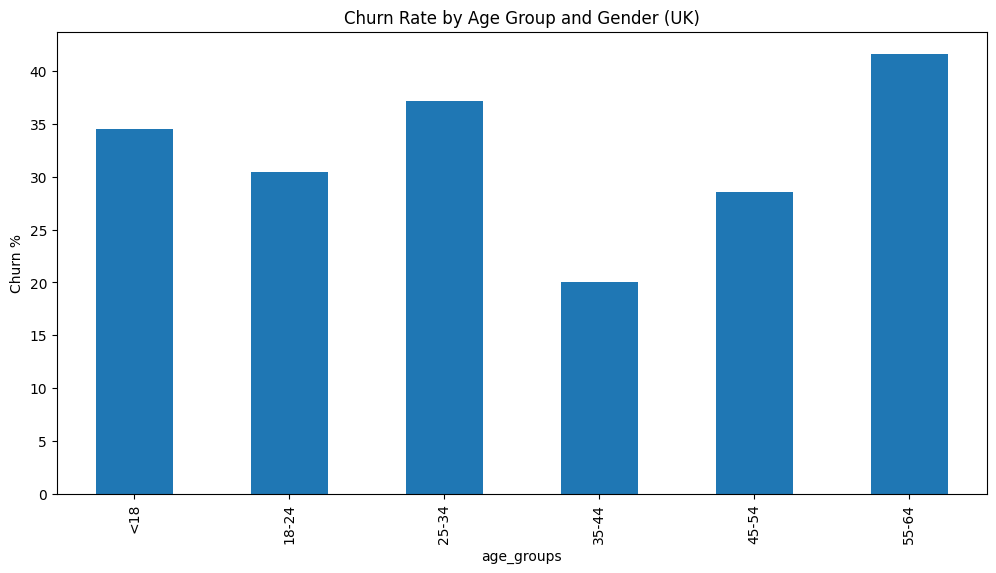

In [13]:
uk_age_churn_yes = uk_age_churn[1] 

uk_age_churn_yes.plot(kind='bar', figsize=(12,6))
plt.ylabel('Churn %')
plt.title('Churn Rate by Age Group and Gender (UK)')
plt.show()

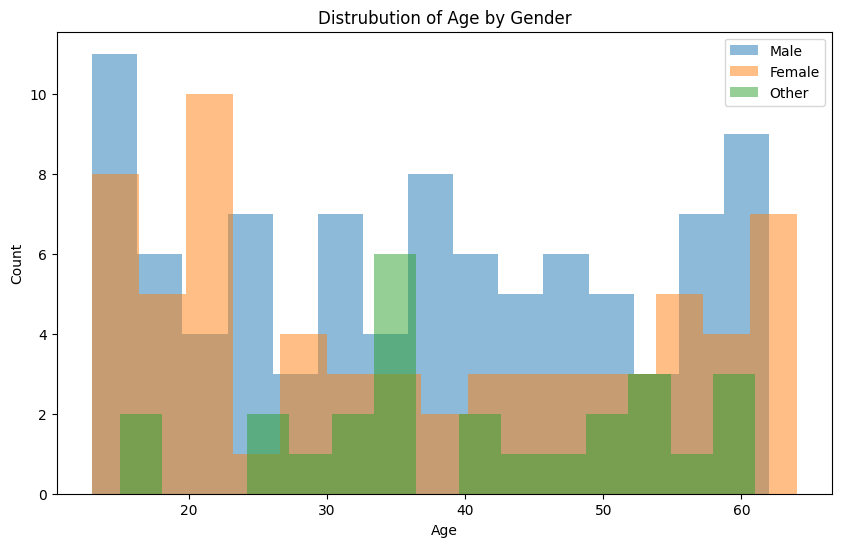

In [14]:
plt.figure(figsize=(10, 6))
for gender in ['Male', 'Female', 'Other']:
    subset = uk_data[uk_data['gender'] == gender]
    plt.hist(subset['age'], bins=15, alpha=0.5, label=gender)

plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Distrubution of Age by Gender')
plt.legend()
plt.show()

In [15]:
uk_data.head(20)

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date,age_groups
5,U1691,united kingdom,16,Female,Student,11.0,548,0.30,3.000000,0,9.99,25/04/2022,<18
7,U1490,united kingdom,57,Female,Premium,11.3,476,0.30,3.000000,0,7.99,01/12/2022,55-64
12,U1387,united kingdom,49,Female,Free,11.2,508,0.10,5.000000,1,9.99,05/02/2022,45-54
17,U1508,united kingdom,48,Female,Family,8.7,511,0.30,4.000000,1,0.00,18/09/2022,45-54
22,U1424,united kingdom,26,Female,Student,9.5,498,0.10,3.000000,0,9.99,11/10/2022,25-34
23,U1038,united kingdom,48,Male,Free,6.7,485,0.15,2.000000,0,9.99,21/02/2023,45-54
35,U1382,united kingdom,25,Other,Premium,9.0,442,0.20,5.000000,0,9.99,29/06/2022,18-24
36,U1340,united kingdom,61,Other,Student,6.9,519,0.15,2.000000,1,12.99,13/12/2022,55-64
43,U1247,united kingdom,40,Other,Family,3.2,507,0.10,3.000000,0,12.99,07/09/2022,35-44
49,U1454,united kingdom,63,Female,Free,11.3,492,0.10,1.000000,0,9.99,09/09/2022,55-64


In [16]:
uk_gender_age_churn =(uk_data.groupby(['age_groups','gender'])['churned'].value_counts(normalize= True).unstack()[1]*100)
print("percentage of gender and age churn in United kingdom")
print(uk_gender_age_churn)

percentage of gender and age churn in United kingdom
age_groups  gender
<18         Female    36.363636
            Male      37.500000
            Other      0.000000
18-24       Female    33.333333
            Male      30.000000
            Other      0.000000
25-34       Female    40.000000
            Male      50.000000
            Other     11.111111
35-44       Female    14.285714
            Male      26.315789
            Other      0.000000
45-54       Female    37.500000
            Male      21.428571
            Other     33.333333
55-64       Female    31.250000
            Male      50.000000
            Other     50.000000
Name: 1, dtype: float64


C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_25332\3822810160.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uk_gender_age_churn =(uk_data.groupby(['age_groups','gender'])['churned'].value_counts(normalize= True).unstack()[1]*100)


<Figure size 1200x600 with 0 Axes>

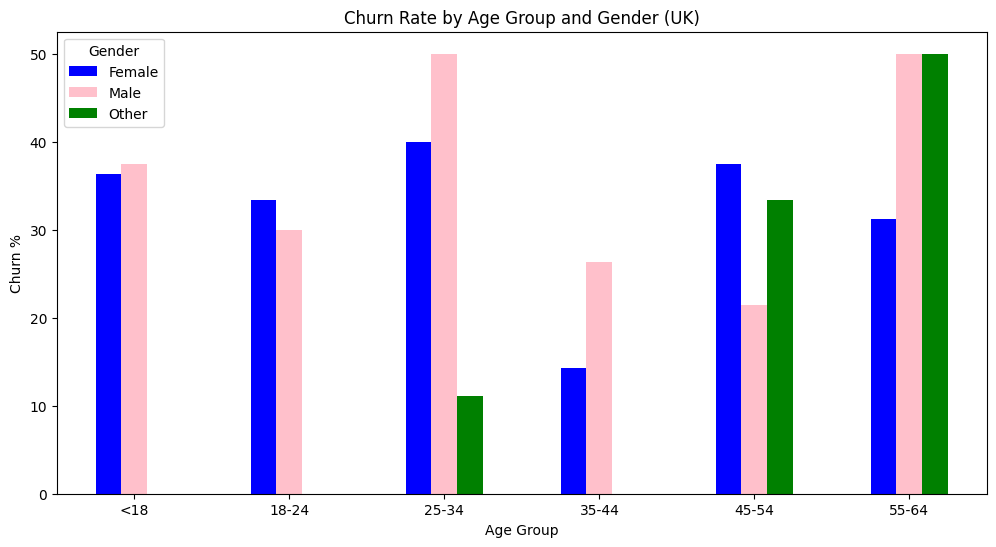

In [17]:
plt.figure(figsize=(12,6))
uk_gender_age_churn.unstack().plot(
    kind='bar',
    figsize=(12,6),
    color=['blue', 'pink', 'green']  # colors for M, F, O
)

plt.ylabel('Churn %')
plt.xlabel('Age Group')
plt.title('Churn Rate by Age Group and Gender (UK)')
plt.legend(title='Gender')
plt.xticks(rotation=0)
plt.show()

In [18]:
subbscription_fee =uk_data['monthly_fee'].unique()
print("Monthly fee paid bby userd in Uk")
print(subbscription_fee)

Monthly fee paid bby userd in Uk
[ 9.99  7.99  0.   12.99  5.  ]


In [19]:
uk_data['join_date']= pd.to_datetime(uk_data['join_date'])
uk_data['join_year'] = uk_data['join_date'].dt.year
uk_data

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_25332\1765371121.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  uk_data['join_date']= pd.to_datetime(uk_data['join_date'])
C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_25332\1765371121.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_data['join_date']= pd.to_datetime(uk_data['join_date'])
C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_25332\1765371121.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date,age_groups,join_year
5,U1691,united kingdom,16,Female,Student,11.0,548,0.30,3.0,0,9.99,2022-04-25,<18,2022
7,U1490,united kingdom,57,Female,Premium,11.3,476,0.30,3.0,0,7.99,2022-12-01,55-64,2022
12,U1387,united kingdom,49,Female,Free,11.2,508,0.10,5.0,1,9.99,2022-02-05,45-54,2022
17,U1508,united kingdom,48,Female,Family,8.7,511,0.30,4.0,1,0.00,2022-09-18,45-54,2022
22,U1424,united kingdom,26,Female,Student,9.5,498,0.10,3.0,0,9.99,2022-10-11,25-34,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,U1104,united kingdom,22,Female,Premium,2.0,497,0.25,5.0,0,9.99,2023-07-12,18-24,2023
676,U1679,united kingdom,40,Other,Free,2.1,462,0.25,1.0,0,9.99,2022-06-06,35-44,2022
678,U1229,united kingdom,34,Male,Free,19.4,508,0.25,1.0,0,7.99,2022-08-04,25-34,2022
687,U1418,united kingdom,42,Male,Family,6.7,507,0.25,5.0,0,0.00,2024-07-02,35-44,2024


In [20]:
def calculate_months(start_date, end_date):
    rd= relativedelta(end_date, start_date)
    return rd.years * 12 + rd.months

In [21]:
today = pd.Timestamp.today()
uk_data['months_active'] = uk_data['join_date'].apply(lambda x:calculate_months(x, today))
uk_data # adding months active to understand if the lognterm user are leaving or short term

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_25332\1905405561.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_data['months_active'] = uk_data['join_date'].apply(lambda x:calculate_months(x, today))


,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date,age_groups,join_year,months_active
5,U1691,united kingdom,16,Female,Student,11.0,548,0.30,3.0,0,9.99,2022-04-25,<18,2022,42
7,U1490,united kingdom,57,Female,Premium,11.3,476,0.30,3.0,0,7.99,2022-12-01,55-64,2022,35
12,U1387,united kingdom,49,Female,Free,11.2,508,0.10,5.0,1,9.99,2022-02-05,45-54,2022,45
17,U1508,united kingdom,48,Female,Family,8.7,511,0.30,4.0,1,0.00,2022-09-18,45-54,2022,38
22,U1424,united kingdom,26,Female,Student,9.5,498,0.10,3.0,0,9.99,2022-10-11,25-34,2022,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,U1104,united kingdom,22,Female,Premium,2.0,497,0.25,5.0,0,9.99,2023-07-12,18-24,2023,28
676,U1679,united kingdom,40,Other,Free,2.1,462,0.25,1.0,0,9.99,2022-06-06,35-44,2022,41
678,U1229,united kingdom,34,Male,Free,19.4,508,0.25,1.0,0,7.99,2022-08-04,25-34,2022,39
687,U1418,united kingdom,42,Male,Family,6.7,507,0.25,5.0,0,0.00,2024-07-02,35-44,2024,16


In [51]:
np.unique(uk_data['months_active'])


array([11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28,
       29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45,
       46], dtype=int64)

In [53]:
uk_data['tenure_group'] = pd.cut(
    uk_data['months_active'],
    bins=[10, 15, 20, 25, 30, 35, 40, 45],
    labels=['11–15 Mo', '16–20 Mo', '21–25 Mo', '26–30 Mo', '31–35 Mo', '36–40 Mo',  '41–45 Mo']
)

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_25332\757891206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_data['tenure_group'] = pd.cut(


In [54]:
month_churn_pivot = uk_data.pivot_table(
    values= 'churned',
    index='tenure_group', aggfunc='mean'
)*100

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_25332\1819352982.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  month_churn_pivot = uk_data.pivot_table(


In [59]:
monthly_churn= uk_data.groupby('months_active')['churned'].mean()*100

In [61]:
highest_churn_month = monthly_churn.idxmax()
highest_churn_rate = monthly_churn.max()
print(f"Highest churn occurs at month {highest_churn_month} with churn rate {highest_churn_rate:.2f}%")

lowest_churn_month = monthly_churn.idxmin()
lowest_churn_rate = monthly_churn.idxmin()
print(f"Highest churn occurs at month {lowest_churn_month} with churn rate {lowest_churn_rate:.2f}%")

Highest churn occurs at month 14 with churn rate 66.67%
Highest churn occurs at month 11 with churn rate 11.00%


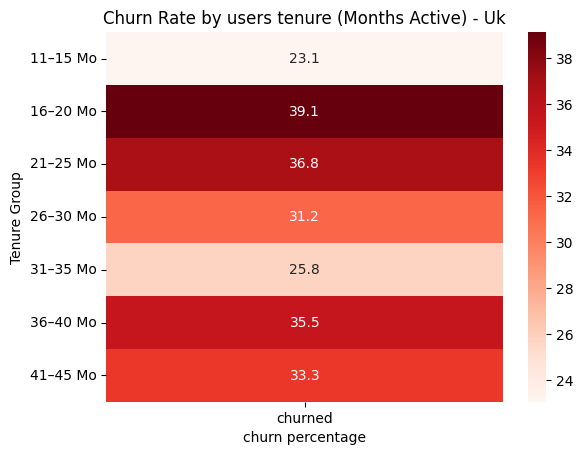

In [55]:
plt.Figure(figsize=(12,6))
sns.heatmap(month_churn_pivot, annot= True, fmt='.1f', cmap = 'Reds')
plt.title   ('Churn Rate by users tenure (Months Active) - Uk')
plt.ylabel("Tenure Group")
plt.xlabel('churn percentage')
plt.show()

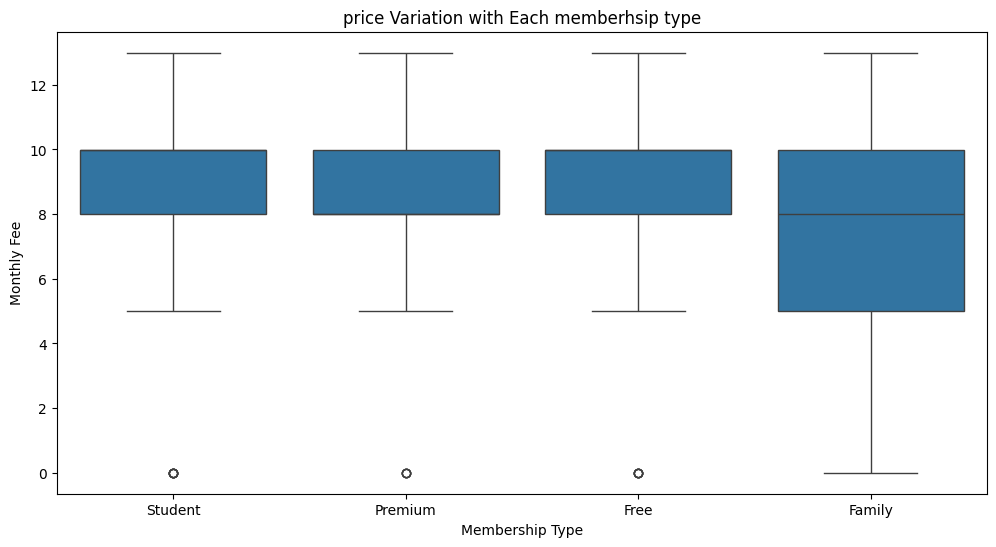

In [62]:
plt.figure(figsize=(12,6))
sns.boxplot(x= 'subscription_type', y='monthly_fee', data = uk_data)
plt.title('price Variation with Each memberhsip type')
plt.ylabel('Monthly Fee')
plt.xlabel('Membership Type')
plt.show()

In [66]:
price_churn_membership = uk_data.groupby(['subscription_type', 'monthly_fee'])['churned'].mean()*100
price_churn_membership = price_churn_membership.reset_index()
price_churn_membership.rename(columns={'churned':'churn_rate'}, inplace= True)

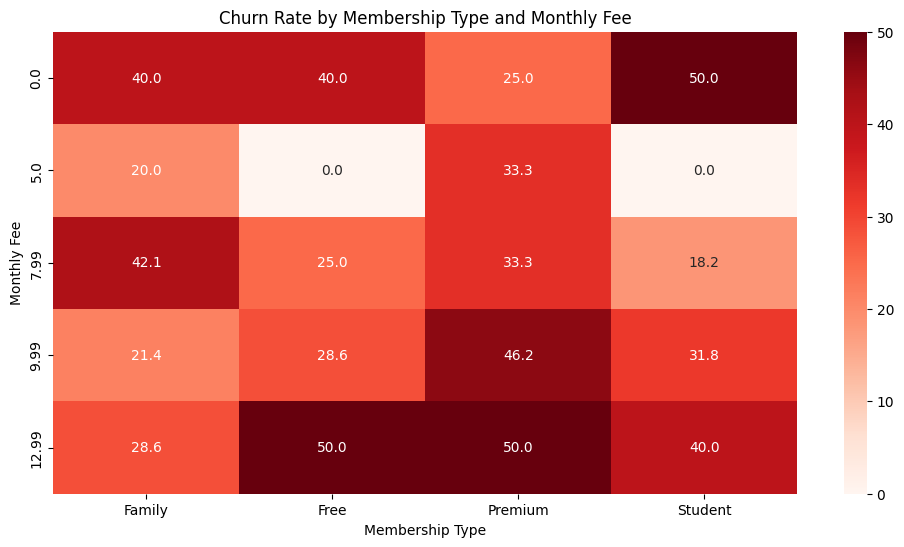

In [68]:
pivot = price_churn_membership.pivot(index='monthly_fee', columns='subscription_type', values='churn_rate')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap='Reds')
plt.title('Churn Rate by Membership Type and Monthly Fee')
plt.ylabel('Monthly Fee')
plt.xlabel('Membership Type')
plt.show()

In [69]:
uk_data.groupby(['subscription_type','monthly_fee']).size()

subscription_type  monthly_fee
Family             0.00           10
                   5.00            5
                   7.99           19
                   9.99           14
                   12.99           7
Free               0.00            5
                   5.00            2
                   7.99            8
                   9.99           14
                   12.99           2
Premium            0.00            4
                   5.00            3
                   7.99           15
                   9.99           13
                   12.99           6
Student            0.00            6
                   5.00            5
                   7.99           11
                   9.99           22
                   12.99          10
dtype: int64

In [71]:
uk_data.groupby(['subscription_type','monthly_fee'])['join_date'].min()

subscription_type  monthly_fee
Family             0.00          2022-04-14
                   5.00          2022-05-11
                   7.99          2022-01-23
                   9.99          2022-06-16
                   12.99         2022-02-05
Free               0.00          2022-05-26
                   5.00          2023-02-23
                   7.99          2022-07-05
                   9.99          2022-02-05
                   12.99         2024-08-30
Premium            0.00          2022-03-09
                   5.00          2022-04-02
                   7.99          2022-03-03
                   9.99          2022-06-29
                   12.99         2022-05-06
Student            0.00          2023-05-27
                   5.00          2022-05-13
                   7.99          2022-03-23
                   9.99          2022-01-18
                   12.99         2022-01-17
Name: join_date, dtype: datetime64[ns]